# 10: Multiple Treatments and Continuous Treatments

Most introductory causal examples use a binary treatment: treated or not treated. Real decision systems are often richer than that. A product team might choose among several intervention types, a pricing team might choose a discount amount, and an operations team might choose how much support or attention to allocate.

We extend the EconML tutorial sequence beyond binary treatment in two directions:

- **multiple discrete treatments**, where the decision is one of several mutually exclusive arms;
- **continuous treatments**, where the decision is a dose, intensity, price, time, or quantity.

These settings require a careful shift in language. Instead of asking only “what is the effect of treatment versus control?”, we ask:

- What is the effect of arm 1 versus control?
- What is the effect of arm 2 versus control?
- Which arm has the largest expected gain for a given covariate profile?
- How much does the outcome change when the continuous treatment increases by one unit?
- Does the estimated marginal effect vary across segments?

We will use synthetic example data with known ground truth, so we can check whether the estimators recover the right arm rankings and dose-response slopes.


## Learning Goals

By the end, you should be able to:

- define estimands for multi-arm and continuous-treatment settings;
- simulate confounded multi-arm treatment assignment and continuous treatment intensity;
- use `DRLearner` for multi-arm heterogeneous treatment effects;
- estimate treatment effects for each arm relative to a control arm;
- translate arm-specific CATE estimates into an estimated best-arm policy;
- use `LinearDML` for continuous treatment effects;
- interpret marginal effects and finite dose contrasts;
- diagnose overlap, dose support, and segment-level treatment-effect recovery.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Multiple Treatments And Continuous Treatments**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment goes beyond a single binary treatment. Treatment coding, dosage, and contrast definitions become part of the estimand.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

With multiple treatments, the estimand compares potential outcomes under different arms,

$$
\tau_{a,b}(x)=\mathbb{E}\{Y(a)-Y(b)\mid X=x\}.
$$

With a continuous treatment dose $d$, a response curve is

$$
\mu(d,x)=\mathbb{E}\{Y(d)\mid X=x\}.
$$

These estimands require support across arms or dose levels within the relevant covariate region.



The lesson has two worked case studies.

First, we build a three-arm discrete treatment dataset. We fit an EconML `DRLearner`, estimate effects for each active arm versus control, and evaluate an estimated best-arm policy against the known synthetic truth.

Second, we build a continuous-dose dataset. We fit `LinearDML`, estimate heterogeneous marginal dose effects, compare them with the true slope, and inspect where the estimated dose effect is strongest.

The two parts use different estimators because the treatment structure is different. That is the main lesson: the causal question determines the estimator interface.





## Tutorial Workflow

#### Setup

The code below imports the lesson dependencies, creates output folders, and sets plotting defaults. The warning filters remove harmless display and pandas-to-NumPy conversion messages so the saved lesson stays readable.


In [ ]:
from pathlib import Path
import os
import warnings
# Suppress optional widget warnings that can appear while importing EconML in headless notebook runs.
warnings.filterwarnings("ignore", message="IProgress not found.*")
# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import econml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default
    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import seaborn as sns
from IPython.display import display
from scipy.special import softmax
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from econml.dr import DRLearner
from econml.dml import LinearDML
warnings.filterwarnings("ignore", message="X does not have valid feature names.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Not all column names are strings.*", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
def find_project_root(start=None):
    """
    Find the repository root from either the repo or a nested notebook folder.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    
    Returns
    -------
    pathlib.Path
        Repository root inferred from the current working directory or its parents.
    """
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()
PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "econml"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(202610)
print(f"Project root: {PROJECT_ROOT}")
print(f"EconML version: {econml.__version__}")


The environment is ready. We will save all tables and plots with the `10_` prefix so they remain easy to separate from earlier tutorial outputs.


### Estimand Map

Multi-arm and continuous-treatment problems use different estimands. This table gives the vocabulary we will use before the code starts creating data.


| setting | treatment_example | estimand | econml_call_pattern | decision_question |
| --- | --- | --- | --- | --- |
| Binary treatment | 0 or 1 | Effect of treatment 1 versus treatment 0 | est.effect(X) | Should this unit receive the intervention? |
| Multiple discrete treatments | 0, 1, or 2 | Effect of each active arm versus a baseline arm | est.effect(X, T0=0, T1=arm) | Which arm should this unit receive? |
| Continuous treatment | Dose, intensity, discount, exposure time | Marginal effect of increasing the treatment by one unit | est.const_marginal_effect(X) or est.effect(X, T0=a, T1=b) | How much should the treatment intensity change? |


The key distinction is the contrast. Multi-arm treatment effects are relative to another arm, while continuous-treatment effects are usually marginal slopes or finite dose changes.


# Part a: Multiple Discrete Treatments

In this section, the treatment has three possible arms. Arm `0` is the baseline experience. Arm `1` is a guided personalization intervention. Arm `2` is an exploration-oriented intervention. Each active arm helps different kinds of rows.


### Multi-Arm Treatment Definitions

A multi-arm analysis should name each treatment arm clearly before modeling. This avoids a common mistake: interpreting arm-specific CATE estimates without remembering which baseline they are relative to.


| arm | name | description | role |
| --- | --- | --- | --- |
| 0 | baseline experience | No active intervention beyond the standard experience. | Reference arm for treatment-effect contrasts. |
| 1 | guided personalization | A focused intervention intended to help high-need, already-engaged rows. | Active arm compared against baseline. |
| 2 | exploration boost | A broader discovery-oriented intervention intended to help novelty-seeking rows. | Active arm compared against baseline. |


The reference arm is arm `0`. Every arm-specific effect we estimate in this section will be read as “switching from baseline to this arm,” unless explicitly stated otherwise.


#### Multi-Arm Example Data

The code below creates a confounded three-arm observational dataset. Treatment assignment depends on observed covariates, and each active arm has its own heterogeneous treatment effect. Because we know the true arm effects, we can evaluate whether the model learns the right contrasts.


In [2]:
# Define reusable helpers for the Multi-Arm Example Data section.
def true_arm_effects(frame):
    """
    Return true treatment effects for arm 1 and arm 2 versus baseline.
    
    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    tuple
        Tuple containing tau_arm_1, tau_arm_2.
    """
    tau_arm_1 = (
        0.25
        + 0.34 * frame["baseline_need"]
        + 0.18 * frame["prior_engagement"]
        - 0.22 * np.maximum(frame["friction_score"], 0)
        + 0.16 * frame["content_affinity"]
        - 0.12 * frame["price_sensitivity"]
        + 0.14 * frame["high_need_segment"] * (frame["content_affinity"] > 0).astype(float)
    )
    tau_arm_2 = (
        0.18
        + 0.42 * frame["novelty_preference"]
        + 0.18 * frame["content_affinity"]
        - 0.18 * frame["friction_score"]
        - 0.22 * frame["price_sensitivity"]
        + 0.20 * frame["low_friction_segment"]
        - 0.16 * frame["region_risk"]
    )
    return tau_arm_1, tau_arm_2
n_multi = 4_200
baseline_need = rng.normal(0, 1, size=n_multi)
prior_engagement = rng.normal(0, 1, size=n_multi)
friction_score = rng.normal(0, 1, size=n_multi)
content_affinity = rng.normal(0, 1, size=n_multi)
novelty_preference = rng.normal(0, 1, size=n_multi)
price_sensitivity = rng.beta(2.0, 3.2, size=n_multi)
account_tenure = rng.gamma(shape=3.2, scale=16.0, size=n_multi)
region_risk = rng.binomial(1, 0.30, size=n_multi)
high_need_segment = (baseline_need > 0.55).astype(int)
low_friction_segment = (friction_score < -0.25).astype(int)
multi_features = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "novelty_preference": novelty_preference,
        "price_sensitivity": price_sensitivity,
        "account_tenure": account_tenure,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "low_friction_segment": low_friction_segment,
    }
)
tau_arm_1, tau_arm_2 = true_arm_effects(multi_features)
# Softmax assignment creates three probabilities that sum to one for every row.
assignment_logits = np.column_stack(
    [
        np.zeros(n_multi),
        -0.15 + 0.55 * baseline_need + 0.35 * prior_engagement - 0.25 * friction_score + 0.15 * high_need_segment,
        -0.25 + 0.60 * novelty_preference + 0.28 * content_affinity - 0.35 * friction_score - 0.20 * price_sensitivity,
    ]
)
arm_probabilities = softmax(assignment_logits, axis=1)
treatment_arm = np.array([rng.choice([0, 1, 2], p=row) for row in arm_probabilities])
base_outcome = (
    1.20
    + 0.52 * baseline_need
    + 0.42 * prior_engagement
    - 0.30 * friction_score
    + 0.28 * content_affinity
    + 0.18 * novelty_preference
    - 0.20 * price_sensitivity
    + 0.10 * np.log1p(account_tenure)
    - 0.18 * region_risk
)
observed_arm_effect = np.select([treatment_arm == 1, treatment_arm == 2], [tau_arm_1, tau_arm_2], default=0.0)
noise = rng.normal(0, 0.72 + 0.12 * np.maximum(friction_score, 0), size=n_multi)
outcome = base_outcome + observed_arm_effect + noise
multi_df = multi_features.assign(
    treatment_arm=treatment_arm,
    outcome=outcome,
    true_tau_arm_1=tau_arm_1,
    true_tau_arm_2=tau_arm_2,
    true_best_arm=np.select([tau_arm_1 >= tau_arm_2, tau_arm_2 > tau_arm_1], [1, 2], default=0),
    true_best_gain=np.maximum.reduce([np.zeros(n_multi), tau_arm_1, tau_arm_2]),
    propensity_arm_0=arm_probabilities[:, 0],
    propensity_arm_1=arm_probabilities[:, 1],
    propensity_arm_2=arm_probabilities[:, 2],
)
multi_df.to_csv(TABLE_DIR / "10_multi_arm_teaching_data.csv", index=False)
multi_df.head()


,baseline_need,prior_engagement,friction_score,content_affinity,novelty_preference,price_sensitivity,account_tenure,region_risk,high_need_segment,low_friction_segment,treatment_arm,outcome,true_tau_arm_1,true_tau_arm_2,true_best_arm,true_best_gain,propensity_arm_0,propensity_arm_1,propensity_arm_2
0,0.366699,0.788056,-1.033327,0.016613,1.898511,0.730055,16.504243,0,0,1,1,4.710258,0.431579,1.205752,2,1.205752,0.171554,0.308195,0.520250
1,-1.477647,-1.192684,0.620291,0.996576,-0.435500,0.673838,83.747364,1,0,0,0,-0.689352,-0.524956,-0.243423,2,0.000000,0.564016,0.121494,0.314490
2,0.169237,0.593231,1.007284,1.253764,-0.006661,0.120508,58.057481,0,0,0,1,2.470206,0.378861,0.195057,1,0.378861,0.375950,0.339797,0.284253
3,-0.829332,-0.303955,0.258781,0.306218,0.739385,0.342374,37.870933,0,0,0,0,1.103533,-0.135707,0.423758,2,0.423758,0.386466,0.177653,0.435881
4,2.048225,-0.908117,0.238080,-0.572745,0.748101,0.792995,49.759960,0,1,0,1,3.410102,0.543759,0.173795,1,0.543759,0.254378,0.538068,0.207553


The first rows include observed covariates, the assigned treatment arm, the outcome, and teaching-only truth columns. In a real dataset we would observe the assigned arm and outcome, but not the true arm-specific effects.


#### Multi-Arm Field Dictionary

The synthetic data has more moving pieces than a binary example, so a field dictionary is helpful. It separates observed inputs from treatment, outcome, and teaching-only ground truth.


| field | role | description |
| --- | --- | --- |
| baseline_need | Observed covariate | Pre-treatment need or demand signal. |
| prior_engagement | Observed covariate | Historical engagement before arm assignment. |
| friction_score | Observed covariate | Higher values mean more user or process friction. |
| content_affinity | Observed covariate | Match between row and content or offer. |
| novelty_preference | Observed covariate | Preference for exploratory or new experiences. |
| price_sensitivity | Observed covariate | Sensitivity to cost, effort, or inconvenience. |
| account_tenure | Observed covariate | Age of the account or relationship in weeks. |
| region_risk | Observed covariate | Binary marker for lower baseline outcome regions. |
| high_need_segment | Observed covariate | Binary segment derived from baseline need. |
| low_friction_segment | Observed covariate | Binary segment derived from friction score. |
| treatment_arm | Treatment | Observed arm assignment: 0, 1, or 2. |
| outcome | Outcome | Observed post-treatment outcome. |
| true_tau_arm_1 | Teaching-only truth | True effect of arm 1 versus baseline. |
| true_tau_arm_2 | Teaching-only truth | True effect of arm 2 versus baseline. |
| true_best_arm | Teaching-only truth | Arm with the largest true expected gain. |
| true_best_gain | Teaching-only truth | Largest true gain across arms. |
| propensity_arm_0 | Teaching-only truth | Synthetic probability of receiving arm 0. |
| propensity_arm_1 | Teaching-only truth | Synthetic probability of receiving arm 1. |
| propensity_arm_2 | Teaching-only truth | Synthetic probability of receiving arm 2. |


The teaching-only columns make this lesson measurable. They let us check arm-specific CATE recovery and best-arm accuracy after fitting the estimator.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Multi-Arm Basic Summary

The code below summarizes sample size, treatment shares, outcome levels, and true effects by assigned arm. The assigned-arm summaries are descriptive; they are not causal effects because assignment is confounded.


In [3]:
multi_basic_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "arm_0_rate",
            "arm_1_rate",
            "arm_2_rate",
            "outcome_mean",
            "true_tau_arm_1_mean",
            "true_tau_arm_2_mean",
            "true_best_gain_mean",
            "share_arm_1_oracle_best",
            "share_arm_2_oracle_best",
        ],
        "value": [
            len(multi_df),
            multi_df.shape[1],
            (multi_df["treatment_arm"] == 0).mean(),
            (multi_df["treatment_arm"] == 1).mean(),
            (multi_df["treatment_arm"] == 2).mean(),
            multi_df["outcome"].mean(),
            multi_df["true_tau_arm_1"].mean(),
            multi_df["true_tau_arm_2"].mean(),
            multi_df["true_best_gain"].mean(),
            (multi_df["true_best_arm"] == 1).mean(),
            (multi_df["true_best_arm"] == 2).mean(),
        ],
    }
)
arm_summary = (
    multi_df.groupby("treatment_arm")
    .agg(
        rows=("outcome", "size"),
        outcome_mean=("outcome", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        novelty_preference_mean=("novelty_preference", "mean"),
        true_tau_arm_1_mean=("true_tau_arm_1", "mean"),
        true_tau_arm_2_mean=("true_tau_arm_2", "mean"),
    )
    .reset_index()
)
multi_basic_summary.to_csv(TABLE_DIR / "10_multi_arm_basic_summary.csv", index=False)
arm_summary.to_csv(TABLE_DIR / "10_multi_arm_observed_arm_summary.csv", index=False)
display(multi_basic_summary)
display(arm_summary)


,metric,value
0,rows,4200.000000
1,columns,19.000000
2,arm_0_rate,0.360238
3,arm_1_rate,0.341905
4,arm_2_rate,0.297857
5,outcome_mean,1.641436
6,true_tau_arm_1_mean,0.135156
7,true_tau_arm_2_mean,0.116860
8,true_best_gain_mean,0.415128
9,share_arm_1_oracle_best,0.513333


,treatment_arm,rows,outcome_mean,baseline_need_mean,novelty_preference_mean,true_tau_arm_1_mean,true_tau_arm_2_mean
0,0,1513,1.197688,-0.174202,-0.203466,0.013935,-0.017544
1,1,1436,1.951341,0.328517,-0.134306,0.287903,0.064246
2,2,1251,1.822385,-0.146132,0.356296,0.106429,0.339809


The assigned arms have different covariate profiles, which is expected because assignment is confounded by construction. That is why arm outcome means should not be read as causal effects.




### Treatment Share Plot

A simple treatment-share plot helps confirm that all arms have enough data. Multi-arm causal estimation becomes fragile when one arm is rare, especially if the rare arm is concentrated in a narrow covariate region.


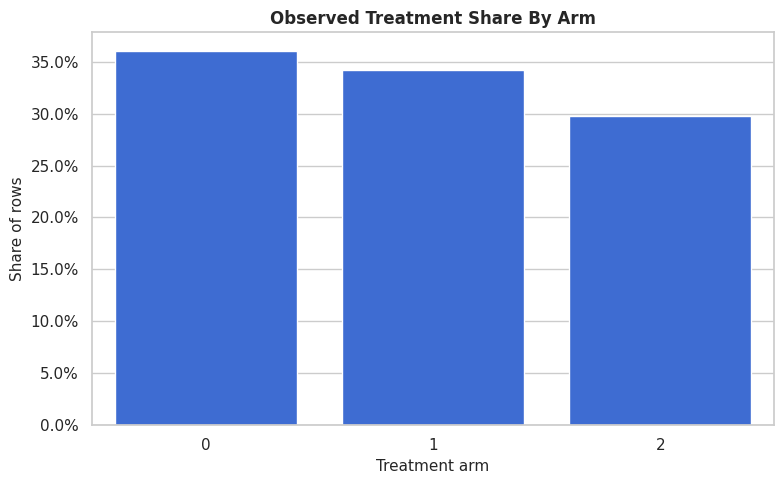

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
arm_counts = multi_df["treatment_arm"].value_counts(normalize=True).rename_axis("treatment_arm").reset_index(name="share")
sns.barplot(data=arm_counts, x="treatment_arm", y="share", color="#2563eb", ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Observed Treatment Share By Arm")
ax.set_xlabel("Treatment arm")
ax.set_ylabel("Share of rows")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_treatment_share.png", dpi=160, bbox_inches="tight")
plt.show()


All three arms have material support. The arms are imbalanced, yet no arm is so rare that the example becomes dominated by sample-size failure.




### True Arm Effect Distributions

Because this is a example dataset, we can inspect the true effect distribution for each active arm. The two distributions are different because each arm helps different row types.


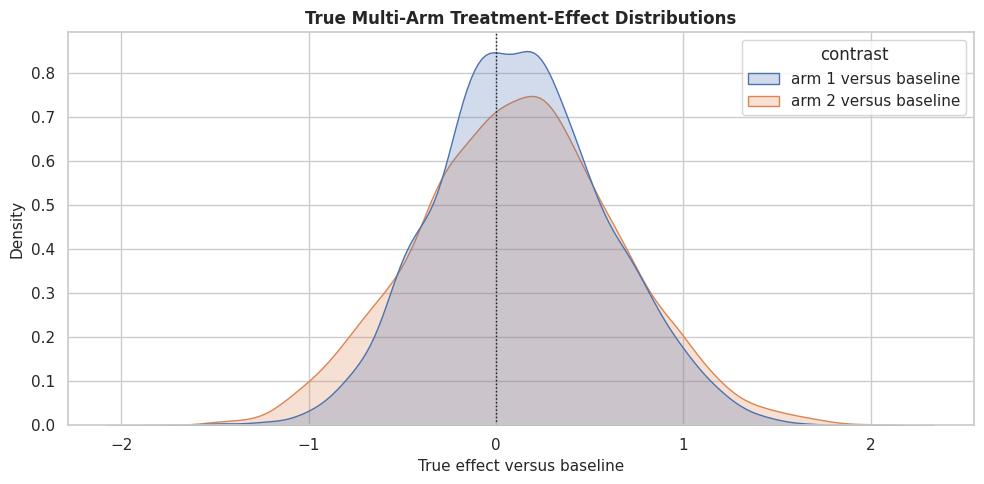

In [5]:
true_effect_long = multi_df[["true_tau_arm_1", "true_tau_arm_2"]].rename(
    columns={"true_tau_arm_1": "arm 1 versus baseline", "true_tau_arm_2": "arm 2 versus baseline"}
).melt(var_name="contrast", value_name="true_effect")
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=true_effect_long, x="true_effect", hue="contrast", fill=True, common_norm=False, alpha=0.25, ax=ax)
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("True Multi-Arm Treatment-Effect Distributions")
ax.set_xlabel("True effect versus baseline")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_true_effect_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The two arms have overlapping but distinct effect distributions. This is the reason multi-arm learning is more than two separate binary questions; the final decision may require comparing both active arms for the same row.




### Naive Arm Differences versus Truth

The code below computes raw outcome differences between each active arm and the baseline arm, then compares those raw differences with the true average arm effects. The gap is a diagnostic view of selection bias.


In [6]:
control_mean = multi_df.loc[multi_df["treatment_arm"] == 0, "outcome"].mean()
naive_arm_rows = []
for arm, true_col in [(1, "true_tau_arm_1"), (2, "true_tau_arm_2")]:
    arm_mean = multi_df.loc[multi_df["treatment_arm"] == arm, "outcome"].mean()
    naive_arm_rows.append(
        {
            "contrast": f"arm {arm} versus baseline",
            "raw_outcome_difference": arm_mean - control_mean,
            "true_average_effect": multi_df[true_col].mean(),
            "raw_minus_true": arm_mean - control_mean - multi_df[true_col].mean(),
        }
    )
naive_arm_comparison = pd.DataFrame(naive_arm_rows)
naive_arm_comparison.to_csv(TABLE_DIR / "10_multi_arm_naive_vs_truth.csv", index=False)
display(naive_arm_comparison)


,contrast,raw_outcome_difference,true_average_effect,raw_minus_true
0,arm 1 versus baseline,0.753653,0.135156,0.618497
1,arm 2 versus baseline,0.624697,0.116860,0.507836


The raw differences are not the same as the true average effects. Multi-arm observational data can have selection bias in every active-arm contrast, so each contrast needs adjustment.


### Multi-Arm Train-Test Split

We split the multi-arm dataset before fitting the estimator. Stratifying by treatment arm keeps all arms represented in both train and test splits.


In [7]:
multi_feature_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "novelty_preference",
    "price_sensitivity",
    "account_tenure",
    "region_risk",
    "high_need_segment",
    "low_friction_segment",
]
multi_train, multi_test = train_test_split(
    multi_df,
    test_size=0.35,
    random_state=202610,
    stratify=multi_df["treatment_arm"],
)
multi_train = multi_train.reset_index(drop=True)
multi_test = multi_test.reset_index(drop=True)
multi_split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(multi_train), len(multi_test)],
        "arm_0_rate": [(multi_train["treatment_arm"] == 0).mean(), (multi_test["treatment_arm"] == 0).mean()],
        "arm_1_rate": [(multi_train["treatment_arm"] == 1).mean(), (multi_test["treatment_arm"] == 1).mean()],
        "arm_2_rate": [(multi_train["treatment_arm"] == 2).mean(), (multi_test["treatment_arm"] == 2).mean()],
        "true_tau_arm_1_mean": [multi_train["true_tau_arm_1"].mean(), multi_test["true_tau_arm_1"].mean()],
        "true_tau_arm_2_mean": [multi_train["true_tau_arm_2"].mean(), multi_test["true_tau_arm_2"].mean()],
    }
)
multi_split_summary.to_csv(TABLE_DIR / "10_multi_arm_train_test_split_summary.csv", index=False)
display(multi_split_summary)


,split,rows,arm_0_rate,arm_1_rate,arm_2_rate,true_tau_arm_1_mean,true_tau_arm_2_mean
0,train,2730,0.360440,0.341758,0.297802,0.130538,0.112445
1,test,1470,0.359864,0.342177,0.297959,0.143733,0.125060


The split keeps treatment shares very similar across train and test. That makes held-out arm-specific diagnostics more stable.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->


#### Multi-Arm Model Matrices

The code below extracts the covariate matrix, treatment-arm vector, and outcome vector. Multi-arm treatments stay as integer labels because `DRLearner` can model the discrete arm assignment process directly.


In [8]:
X_multi_train = multi_train[multi_feature_cols].copy()
X_multi_test = multi_test[multi_feature_cols].copy()
T_multi_train = multi_train["treatment_arm"].to_numpy()
T_multi_test = multi_test["treatment_arm"].to_numpy()
y_multi_train = multi_train["outcome"].to_numpy()
y_multi_test = multi_test["outcome"].to_numpy()
true_tau_1_test = multi_test["true_tau_arm_1"].to_numpy()
true_tau_2_test = multi_test["true_tau_arm_2"].to_numpy()
multi_matrix_summary = pd.DataFrame(
    {
        "object": ["X_multi_train", "X_multi_test", "T_multi_train", "y_multi_train"],
        "shape_or_length": [X_multi_train.shape, X_multi_test.shape, len(T_multi_train), len(y_multi_train)],
        "description": [
            "Observed pre-treatment covariates for multi-arm CATE estimation.",
            "Held-out covariates for evaluating arm-specific effects.",
            "Integer arm labels for the training split.",
            "Observed outcomes for the training split.",
        ],
    }
)
multi_matrix_summary.to_csv(TABLE_DIR / "10_multi_arm_model_matrix_summary.csv", index=False)
display(multi_matrix_summary)


,object,shape_or_length,description
0,X_multi_train,"(2730, 10)",Observed pre-treatment covariates for multi-arm CATE estimation.
1,X_multi_test,"(1470, 10)",Held-out covariates for evaluating arm-specific effects.
2,T_multi_train,2730,Integer arm labels for the training split.
3,y_multi_train,2730,Observed outcomes for the training split.


The treatment vector has three possible values. The estimator will learn the outcome process and the multinomial treatment assignment process from these objects.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->




#### Multi-Arm Nuisance Diagnostics

Before fitting `DRLearner`, we train diagnostic models for arm assignment and outcome prediction. These are limited as the exact internal nuisance fits. They tell us whether the observed covariates carry useful signal.


In [9]:
# Fit or evaluate the model objects used in the Multi-Arm Nuisance Diagnostics section.
arm_propensity_diagnostic = LogisticRegression(max_iter=1_000)
arm_propensity_diagnostic.fit(X_multi_train, T_multi_train)
arm_propensity_pred = np.clip(arm_propensity_diagnostic.predict_proba(X_multi_test), 1e-4, 1 - 1e-4)
arm_outcome_features_train = X_multi_train.assign(treatment_arm=T_multi_train)
arm_outcome_features_test = X_multi_test.assign(treatment_arm=T_multi_test)
arm_outcome_diagnostic = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=20,
    random_state=202611,
    n_jobs=-1,
)
arm_outcome_diagnostic.fit(arm_outcome_features_train, y_multi_train)
arm_outcome_pred = arm_outcome_diagnostic.predict(arm_outcome_features_test)
multi_nuisance_diagnostics = pd.DataFrame(
    [
        {
            "model": "multinomial_arm_model",
            "metric_1": "accuracy",
            "value_1": accuracy_score(T_multi_test, arm_propensity_diagnostic.predict(X_multi_test)),
            "metric_2": "log_loss",
            "value_2": log_loss(T_multi_test, arm_propensity_pred),
        },
        {
            "model": "outcome_model",
            "metric_1": "rmse",
            "value_1": np.sqrt(mean_squared_error(y_multi_test, arm_outcome_pred)),
            "metric_2": "mae",
            "value_2": mean_absolute_error(y_multi_test, arm_outcome_pred),
        },
    ]
)
multi_nuisance_diagnostics.to_csv(TABLE_DIR / "10_multi_arm_nuisance_diagnostics.csv", index=False)
display(multi_nuisance_diagnostics)


,model,metric_1,value_1,metric_2,value_2
0,multinomial_arm_model,accuracy,0.465986,log_loss,1.030364
1,outcome_model,rmse,0.910379,mae,0.716105


The arm model has nontrivial predictive signal, which confirms the observational assignment process is confounded. Doubly robust estimation is useful here because it uses both outcome and treatment-assignment nuisance information.




#### Multi-Arm Propensity Support

For multi-arm treatments, overlap means each arm has a reasonable probability in the regions where we compare arms. The code below summarizes the estimated probability of each arm on held-out rows.


In [10]:
propensity_support = pd.DataFrame(
    arm_propensity_pred,
    columns=["estimated_p_arm_0", "estimated_p_arm_1", "estimated_p_arm_2"],
)
propensity_support_summary = propensity_support.agg(["min", "mean", "median", "max"]).T.reset_index().rename(columns={"index": "propensity"})
propensity_support_summary["share_below_0_10"] = (propensity_support < 0.10).mean().to_numpy()
propensity_support_summary.to_csv(TABLE_DIR / "10_multi_arm_propensity_support_summary.csv", index=False)
display(propensity_support_summary)


,propensity,min,mean,median,max,share_below_0_10
0,estimated_p_arm_0,0.059961,0.355676,0.345325,0.790690,0.007483
1,estimated_p_arm_1,0.030282,0.346332,0.326099,0.830833,0.024490
2,estimated_p_arm_2,0.020873,0.297992,0.273982,0.881861,0.078912


The support summary checks whether any arm has near-zero estimated probability for many rows. When an arm has weak support, its contrast against baseline becomes more fragile.


#### Propensity Support Plot

The table gives exact values, but the distribution plot makes support problems easier to see. Each curve shows the estimated probability of one arm on held-out rows.


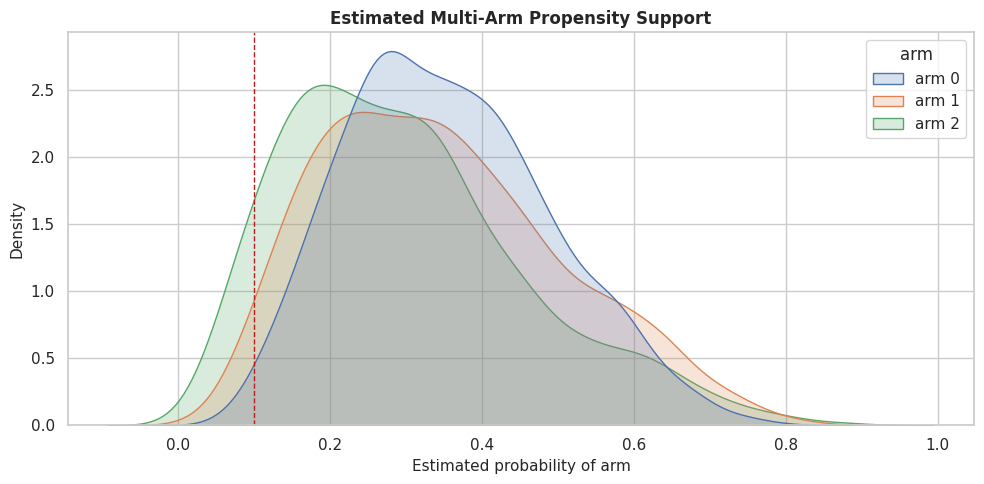

In [11]:
propensity_long = propensity_support.rename(
    columns={
        "estimated_p_arm_0": "arm 0",
        "estimated_p_arm_1": "arm 1",
        "estimated_p_arm_2": "arm 2",
    }
).melt(var_name="arm", value_name="estimated_probability")
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=propensity_long, x="estimated_probability", hue="arm", fill=True, common_norm=False, alpha=0.22, ax=ax)
ax.axvline(0.10, color="#b91c1c", linestyle="--", linewidth=1, label="0.10 support marker")
ax.set_title("Estimated Multi-Arm Propensity Support")
ax.set_xlabel("Estimated probability of arm")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_propensity_support.png", dpi=160, bbox_inches="tight")
plt.show()


The plot shows whether any treatment arm becomes implausible for large parts of the covariate space. Those regions are where arm-specific effect estimates should be handled carefully.


#### Fit Multi-Arm DRLearner

`DRLearner` works well for this section because it is designed for discrete treatments and can use both outcome regression and propensity modeling. We ask it to estimate active-arm effects relative to arm `0`.


In [12]:
multi_dr = DRLearner(
    model_propensity=LogisticRegression(max_iter=1_000),
    model_regression=RandomForestRegressor(
        n_estimators=220,
        min_samples_leaf=20,
        random_state=202612,
        n_jobs=-1,
    ),
    model_final=RandomForestRegressor(
        n_estimators=260,
        min_samples_leaf=18,
        random_state=202613,
        n_jobs=-1,
    ),
    cv=3,
    random_state=202614,
)
multi_dr.fit(y_multi_train, T_multi_train, X=X_multi_train)
estimated_tau_arm_1 = multi_dr.effect(X_multi_test, T0=0, T1=1)
estimated_tau_arm_2 = multi_dr.effect(X_multi_test, T0=0, T1=2)
estimated_tau_arm_2_vs_1 = estimated_tau_arm_2 - estimated_tau_arm_1
print(f"Mean estimated effect, arm 1 versus baseline: {estimated_tau_arm_1.mean():.4f}")
print(f"Mean estimated effect, arm 2 versus baseline: {estimated_tau_arm_2.mean():.4f}")
print(f"Mean estimated effect, arm 2 versus arm 1: {estimated_tau_arm_2_vs_1.mean():.4f}")


Mean estimated effect, arm 1 versus baseline: 0.1223
Mean estimated effect, arm 2 versus baseline: 0.0906
Mean estimated effect, arm 2 versus arm 1: -0.0317


The estimator returns one contrast at a time. Arm `2` versus arm `1` can be formed by subtracting the two baseline-relative estimates because both effects are measured against the same reference arm.




#### Multi-Arm CATE Recovery

With synthetic data, we can compare estimated arm-specific CATEs with the true arm-specific effects. This is a teaching diagnostic for whether the estimator learned the right heterogeneity pattern.


In [13]:
multi_eval = multi_test[multi_feature_cols + ["treatment_arm", "outcome", "true_tau_arm_1", "true_tau_arm_2", "true_best_arm", "true_best_gain"]].copy()
multi_eval["estimated_tau_arm_1"] = estimated_tau_arm_1
multi_eval["estimated_tau_arm_2"] = estimated_tau_arm_2
multi_eval["estimated_tau_arm_2_vs_1"] = estimated_tau_arm_2_vs_1
multi_eval["estimated_best_arm"] = np.argmax(
    np.column_stack([np.zeros(len(multi_eval)), estimated_tau_arm_1, estimated_tau_arm_2]),
    axis=1,
)
multi_eval["estimated_best_gain"] = np.maximum.reduce([np.zeros(len(multi_eval)), estimated_tau_arm_1, estimated_tau_arm_2])
multi_cate_recovery = pd.DataFrame(
    [
        {
            "contrast": "arm 1 versus baseline",
            "true_mean_effect": true_tau_1_test.mean(),
            "estimated_mean_effect": estimated_tau_arm_1.mean(),
            "rmse": np.sqrt(mean_squared_error(true_tau_1_test, estimated_tau_arm_1)),
            "mae": mean_absolute_error(true_tau_1_test, estimated_tau_arm_1),
            "correlation": np.corrcoef(true_tau_1_test, estimated_tau_arm_1)[0, 1],
        },
        {
            "contrast": "arm 2 versus baseline",
            "true_mean_effect": true_tau_2_test.mean(),
            "estimated_mean_effect": estimated_tau_arm_2.mean(),
            "rmse": np.sqrt(mean_squared_error(true_tau_2_test, estimated_tau_arm_2)),
            "mae": mean_absolute_error(true_tau_2_test, estimated_tau_arm_2),
            "correlation": np.corrcoef(true_tau_2_test, estimated_tau_arm_2)[0, 1],
        },
    ]
)
multi_cate_recovery.to_csv(TABLE_DIR / "10_multi_arm_cate_recovery.csv", index=False)
multi_eval.to_csv(TABLE_DIR / "10_multi_arm_heldout_effects.csv", index=False)
display(multi_cate_recovery)


,contrast,true_mean_effect,estimated_mean_effect,rmse,mae,correlation
0,arm 1 versus baseline,0.143733,0.122311,0.335122,0.264454,0.792271
1,arm 2 versus baseline,0.125060,0.090606,0.409344,0.307218,0.758175


The recovery table gives a contrast-by-contrast view. In multi-arm settings, one arm can be estimated well while another is weaker, especially if support differs across arms.


#### Multi-Arm Recovery Plot

This plot puts the two active-arm recovery patterns side by side. Each point is a held-out row, and the diagonal line marks perfect CATE recovery.


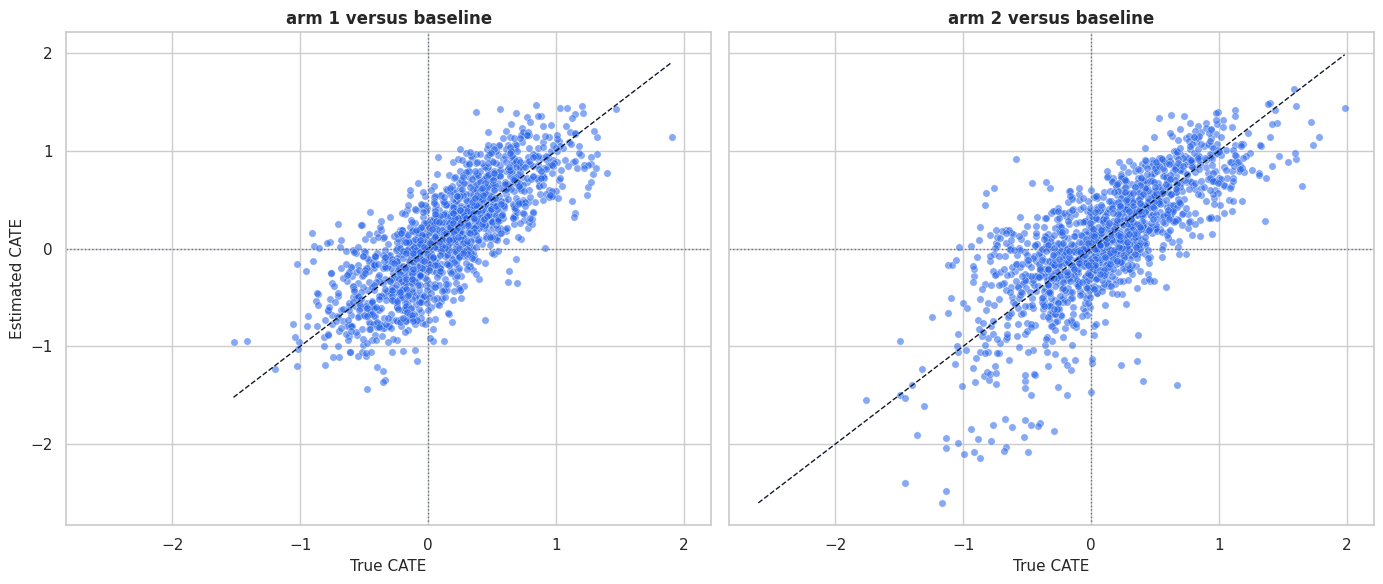

In [14]:
plot_recovery = pd.concat(
    [
        pd.DataFrame({"true_effect": true_tau_1_test, "estimated_effect": estimated_tau_arm_1, "contrast": "arm 1 versus baseline"}),
        pd.DataFrame({"true_effect": true_tau_2_test, "estimated_effect": estimated_tau_arm_2, "contrast": "arm 2 versus baseline"}),
    ],
    ignore_index=True,
)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, contrast in zip(axes, plot_recovery["contrast"].unique()):
    subset = plot_recovery[plot_recovery["contrast"] == contrast]
    sns.scatterplot(data=subset, x="true_effect", y="estimated_effect", alpha=0.55, s=28, color="#2563eb", ax=ax)
    lims = [min(subset["true_effect"].min(), subset["estimated_effect"].min()), max(subset["true_effect"].max(), subset["estimated_effect"].max())]
    ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1)
    ax.axhline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.axvline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.set_title(contrast)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The side-by-side view makes arm-specific strengths and weaknesses visible. A good multi-arm model should recover average effect and ranking qualitys, but also the ordering of arms within rows.




#### Estimated Best-Arm Policy

Multi-arm CATE estimates become useful when we compare arms for each row. The code below chooses the estimated best arm and compares it with the oracle best arm from the synthetic truth.


In [15]:
best_arm_accuracy = accuracy_score(multi_eval["true_best_arm"], multi_eval["estimated_best_arm"])
policy_gain_table = pd.DataFrame(
    [
        {
            "policy": "observed historical assignment",
            "mean_true_gain": np.select(
                [multi_eval["treatment_arm"] == 1, multi_eval["treatment_arm"] == 2],
                [multi_eval["true_tau_arm_1"], multi_eval["true_tau_arm_2"]],
                default=0.0,
            ).mean(),
            "arm_0_rate": (multi_eval["treatment_arm"] == 0).mean(),
            "arm_1_rate": (multi_eval["treatment_arm"] == 1).mean(),
            "arm_2_rate": (multi_eval["treatment_arm"] == 2).mean(),
        },
        {
            "policy": "estimated best arm",
            "mean_true_gain": np.select(
                [multi_eval["estimated_best_arm"] == 1, multi_eval["estimated_best_arm"] == 2],
                [multi_eval["true_tau_arm_1"], multi_eval["true_tau_arm_2"]],
                default=0.0,
            ).mean(),
            "arm_0_rate": (multi_eval["estimated_best_arm"] == 0).mean(),
            "arm_1_rate": (multi_eval["estimated_best_arm"] == 1).mean(),
            "arm_2_rate": (multi_eval["estimated_best_arm"] == 2).mean(),
        },
        {
            "policy": "oracle best arm",
            "mean_true_gain": multi_eval["true_best_gain"].mean(),
            "arm_0_rate": (multi_eval["true_best_arm"] == 0).mean(),
            "arm_1_rate": (multi_eval["true_best_arm"] == 1).mean(),
            "arm_2_rate": (multi_eval["true_best_arm"] == 2).mean(),
        },
    ]
)
best_arm_summary = pd.DataFrame(
    {
        "metric": ["best_arm_accuracy", "estimated_policy_regret_vs_oracle"],
        "value": [
            best_arm_accuracy,
            policy_gain_table.loc[policy_gain_table["policy"] == "oracle best arm", "mean_true_gain"].iloc[0]
            - policy_gain_table.loc[policy_gain_table["policy"] == "estimated best arm", "mean_true_gain"].iloc[0],
        ],
    }
)
policy_gain_table.to_csv(TABLE_DIR / "10_multi_arm_policy_gain_table.csv", index=False)
best_arm_summary.to_csv(TABLE_DIR / "10_multi_arm_best_arm_summary.csv", index=False)
display(best_arm_summary)
display(policy_gain_table)


,metric,value
0,best_arm_accuracy,0.636735
1,estimated_policy_regret_vs_oracle,0.062944


,policy,mean_true_gain,arm_0_rate,arm_1_rate,arm_2_rate
0,observed historical assignment,0.194026,0.359864,0.342177,0.297959
1,estimated best arm,0.361965,0.212925,0.406803,0.380272
2,oracle best arm,0.424909,0.000000,0.523810,0.476190


The estimated policy can improve over historical assignment if the arm-specific estimates rank arms well. The gap to the oracle is regret: value left on the table because the model does not know the true effects perfectly.


#### Best-Arm Policy Plot

The table is precise, but a plot makes the policy comparison easier to communicate. We show both average true gain and how often each policy uses each arm.


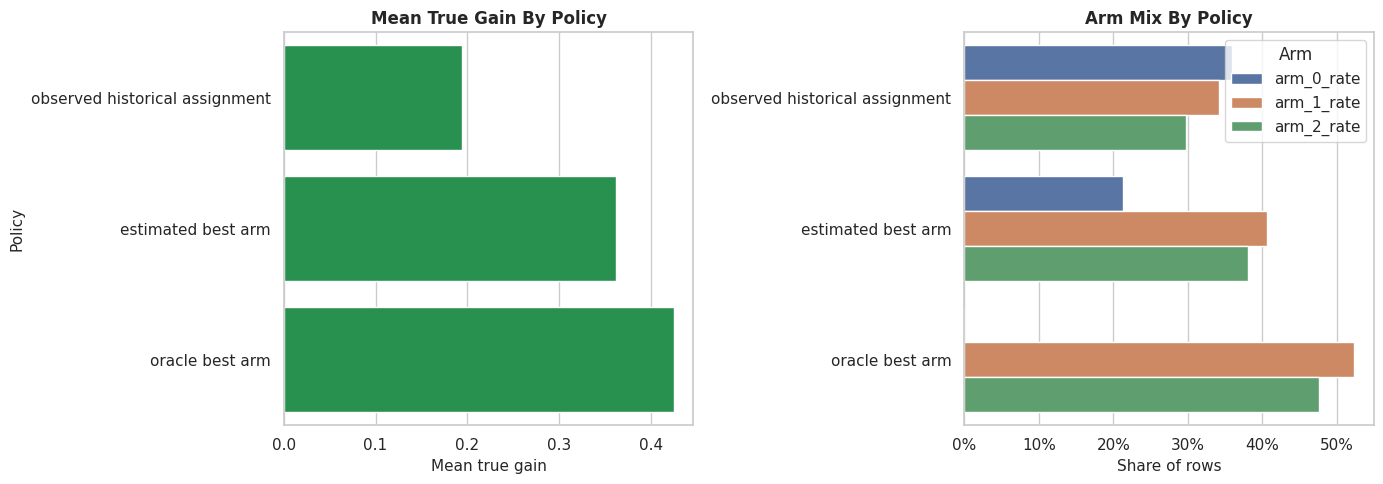

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=policy_gain_table, x="mean_true_gain", y="policy", color="#16a34a", ax=axes[0])
axes[0].set_title("Mean True Gain By Policy")
axes[0].set_xlabel("Mean true gain")
axes[0].set_ylabel("Policy")
arm_mix = policy_gain_table.melt(
    id_vars="policy",
    value_vars=["arm_0_rate", "arm_1_rate", "arm_2_rate"],
    var_name="arm",
    value_name="rate",
)
sns.barplot(data=arm_mix, x="rate", y="policy", hue="arm", ax=axes[1])
axes[1].set_title("Arm Mix By Policy")
axes[1].set_xlabel("Share of rows")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(title="Arm")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The policy view is the payoff of multi-arm estimation. We are no longer asking whether treatment works in general; we are asking which treatment works best for which rows.


#### Segment-Level Arm Effects

A segment summary helps explain the policy in human-readable terms. Here we group by need and novelty preference, then compare true and estimated arm effects within each segment.


In [17]:
segment_multi = multi_eval.copy()
segment_multi["need_segment"] = np.where(segment_multi["baseline_need"] > segment_multi["baseline_need"].median(), "higher need", "lower need")
segment_multi["novelty_segment"] = np.where(segment_multi["novelty_preference"] > segment_multi["novelty_preference"].median(), "higher novelty", "lower novelty")
multi_segment_summary = (
    segment_multi.groupby(["need_segment", "novelty_segment"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_tau_arm_1_mean=("true_tau_arm_1", "mean"),
        estimated_tau_arm_1_mean=("estimated_tau_arm_1", "mean"),
        true_tau_arm_2_mean=("true_tau_arm_2", "mean"),
        estimated_tau_arm_2_mean=("estimated_tau_arm_2", "mean"),
        estimated_arm_1_rate=("estimated_best_arm", lambda s: np.mean(s == 1)),
        estimated_arm_2_rate=("estimated_best_arm", lambda s: np.mean(s == 2)),
    )
    .reset_index()
)
multi_segment_summary.to_csv(TABLE_DIR / "10_multi_arm_segment_summary.csv", index=False)
display(multi_segment_summary)


,need_segment,novelty_segment,rows,true_tau_arm_1_mean,estimated_tau_arm_1_mean,true_tau_arm_2_mean,estimated_tau_arm_2_mean,estimated_arm_1_rate,estimated_arm_2_rate
0,higher need,higher novelty,383,0.445799,0.488359,0.445562,0.389173,0.566580,0.381201
1,higher need,lower novelty,352,0.424514,0.435913,-0.174147,-0.152225,0.758523,0.139205
2,lower need,higher novelty,352,-0.139074,-0.142338,0.464974,0.415551,0.102273,0.747159
3,lower need,lower novelty,383,-0.156471,-0.288730,-0.232856,-0.283431,0.203655,0.263708


The segment table shows why the two arms are different. Guided personalization tends to align with need and engagement, while the exploration arm is designed to align with novelty preference and lower friction.


#### Segment Arm-Effect Plot

The next plot compares estimated active-arm effects by segment. This is often more digestible than individual CATE scatterplots.


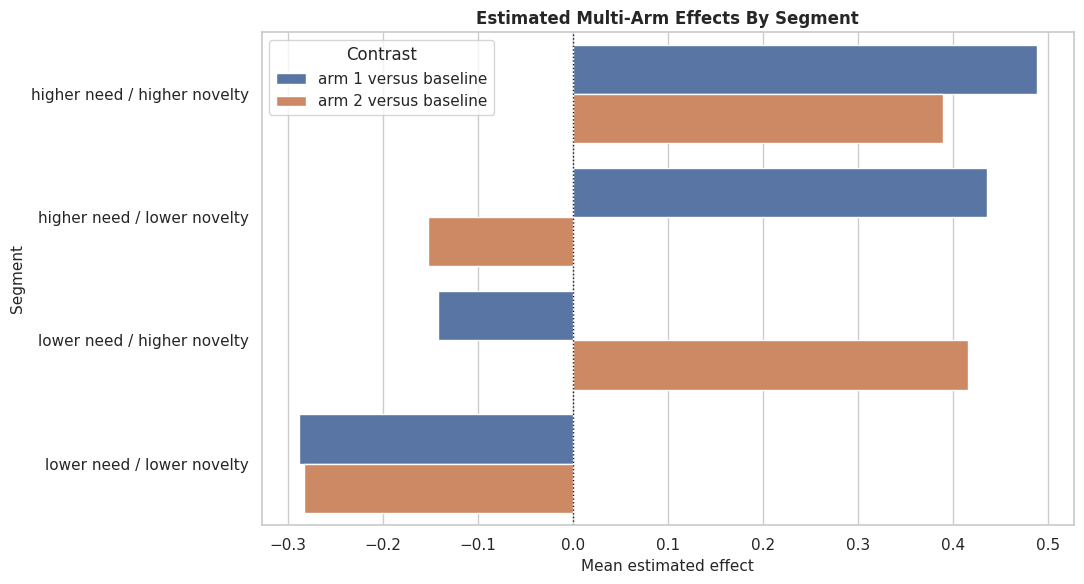

In [18]:
segment_plot = multi_segment_summary.copy()
segment_plot["segment"] = segment_plot["need_segment"] + " / " + segment_plot["novelty_segment"]
segment_effect_plot = segment_plot.melt(
    id_vars="segment",
    value_vars=["estimated_tau_arm_1_mean", "estimated_tau_arm_2_mean"],
    var_name="contrast",
    value_name="estimated_effect",
)
segment_effect_plot["contrast"] = segment_effect_plot["contrast"].map(
    {
        "estimated_tau_arm_1_mean": "arm 1 versus baseline",
        "estimated_tau_arm_2_mean": "arm 2 versus baseline",
    }
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=segment_effect_plot, x="estimated_effect", y="segment", hue="contrast", ax=ax)
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Estimated Multi-Arm Effects By Segment")
ax.set_xlabel("Mean estimated effect")
ax.set_ylabel("Segment")
ax.legend(title="Contrast")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_multi_arm_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The segment plot makes it clear that multi-arm estimation is about matching rows to arms, not simply finding one universally best intervention.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


# Part B: Continuous Treatments

Now we move from choosing among discrete arms to estimating the effect of a continuous dose. The treatment might represent intensity, minutes, discount size, number of recommendations, support hours, or any other continuous amount.


#### Continuous Treatment Estimand

For continuous treatments, the main estimand is often a marginal effect: the expected outcome change for a one-unit increase in treatment intensity, conditional on covariates. We can also ask for a finite contrast such as increasing dose from `0.5` to `1.5`.


| quantity | notation | plain_language | econml_call |
| --- | --- | --- | --- |
| Marginal dose effect | d E[Y(t) \| X] / dt | Outcome change for a small one-unit increase in dose at a covariate profile. | est.const_marginal_effect(X) |
| Finite dose contrast | E[Y(t=b) - Y(t=a) \| X] | Outcome change when moving from dose a to dose b. | est.effect(X, T0=a, T1=b) |
| Dose support check | Observed T distribution by segment | Whether the data contain enough dose variation to support the contrast. | Diagnostic outside the estimator |


Continuous treatments make support especially important. A one-unit contrast is easier to defend when the observed data contain comparable rows with a wide range of treatment intensities.


#### Continuous-Dose Example Data

The code below creates a continuous treatment intensity. The true outcome model is linear in the dose, but the slope varies across covariates. That makes `LinearDML` a good illustrative estimator because it estimates heterogeneous marginal effects.


In [19]:
# Define reusable helpers for the Continuous-Dose Example Data section.
def true_dose_slope(frame):
    """
    Ground-truth marginal effect of one additional treatment-intensity unit.
    
    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle row-level marginal effect of the continuous treatment dose.
    """
    return (
        0.34
        + 0.28 * frame["baseline_need"]
        + 0.18 * frame["content_affinity"]
        - 0.22 * frame["friction_score"]
        - 0.24 * frame["price_sensitivity"]
        + 0.16 * frame["high_capacity_segment"]
        - 0.14 * frame["region_risk"]
    )
n_cont = 3_800
baseline_need = rng.normal(0, 1, size=n_cont)
prior_engagement = rng.normal(0, 1, size=n_cont)
friction_score = rng.normal(0, 1, size=n_cont)
content_affinity = rng.normal(0, 1, size=n_cont)
price_sensitivity = rng.beta(2.1, 3.4, size=n_cont)
capacity_score = rng.normal(0, 1, size=n_cont)
account_tenure = rng.gamma(shape=3.0, scale=15.0, size=n_cont)
region_risk = rng.binomial(1, 0.27, size=n_cont)
high_capacity_segment = (capacity_score > 0.35).astype(int)
continuous_features = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "capacity_score": capacity_score,
        "account_tenure": account_tenure,
        "region_risk": region_risk,
        "high_capacity_segment": high_capacity_segment,
    }
)
true_slope = true_dose_slope(continuous_features)
continuous_treatment = (
    1.20
    + 0.42 * baseline_need
    + 0.35 * prior_engagement
    - 0.32 * friction_score
    + 0.25 * capacity_score
    - 0.28 * price_sensitivity
    + 0.18 * content_affinity
    + rng.normal(0, 0.70, size=n_cont)
)
continuous_treatment = np.clip(continuous_treatment, -1.5, 3.5)
base_continuous_outcome = (
    1.00
    + 0.48 * baseline_need
    + 0.40 * prior_engagement
    - 0.28 * friction_score
    + 0.24 * content_affinity
    - 0.18 * price_sensitivity
    + 0.12 * np.log1p(account_tenure)
    - 0.16 * region_risk
)
continuous_outcome = base_continuous_outcome + true_slope * continuous_treatment + rng.normal(0, 0.72, size=n_cont)
continuous_df = continuous_features.assign(
    treatment_intensity=continuous_treatment,
    outcome=continuous_outcome,
    true_marginal_effect=true_slope,
    true_effect_0_to_1=true_slope,
    true_effect_0_to_2=2 * true_slope,
)
continuous_df.to_csv(TABLE_DIR / "10_continuous_teaching_data.csv", index=False)
continuous_df.head()


,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,capacity_score,account_tenure,region_risk,high_capacity_segment,treatment_intensity,outcome,true_marginal_effect,true_effect_0_to_1,true_effect_0_to_2
0,0.231017,-1.124913,0.230528,-0.138457,0.718611,-1.603517,20.039041,0,0,0.791611,0.747094,0.156580,0.156580,0.313159
1,0.133910,1.097815,-1.259895,0.084472,0.523923,-0.025354,54.492049,1,0,2.056314,3.690250,0.404135,0.404135,0.808271
2,0.119791,-0.673244,-1.596195,2.248898,0.285746,-0.381237,63.664264,0,0,1.978979,5.546482,1.060927,1.060927,2.121854
3,-0.870117,0.008350,0.136661,-0.474915,0.229955,-0.352024,27.547564,0,0,0.977252,0.402511,-0.074372,-0.074372,-0.148744
4,0.181832,0.645825,1.498643,1.464674,0.181864,0.330741,52.486607,0,0,2.077669,1.723572,0.281206,0.281206,0.562411


The treatment is a continuous intensity, not a binary indicator. The truth columns show the marginal effect and finite contrasts that we will use to evaluate the estimator.


#### Continuous Field Dictionary

The continuous-treatment example uses a separate field dictionary so the dose variable is clearly distinguished from the outcome and effect columns.


| field | role | description |
| --- | --- | --- |
| baseline_need | Observed covariate | Pre-treatment need or demand signal. |
| prior_engagement | Observed covariate | Historical engagement before treatment intensity is assigned. |
| friction_score | Observed covariate | Higher values indicate more friction. |
| content_affinity | Observed covariate | Match between row and content or offer. |
| price_sensitivity | Observed covariate | Sensitivity to cost or inconvenience. |
| capacity_score | Observed covariate | Ability to absorb more treatment intensity. |
| account_tenure | Observed covariate | Age of the relationship in weeks. |
| region_risk | Observed covariate | Binary marker for lower baseline outcome regions. |
| high_capacity_segment | Observed covariate | Binary segment derived from capacity score. |
| treatment_intensity | Treatment | Continuous treatment dose or intensity. |
| outcome | Outcome | Observed post-treatment outcome. |
| true_marginal_effect | Teaching-only truth | True one-unit dose effect for each row. |
| true_effect_0_to_1 | Teaching-only truth | True effect of increasing dose from 0 to 1. |
| true_effect_0_to_2 | Teaching-only truth | True effect of increasing dose from 0 to 2. |


The treatment column is numeric and ordered. That changes the modeling goal from estimating arm contrasts to estimating a slope or dose contrast.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->




#### Continuous Treatment Summary

The code below checks the distribution of treatment intensity, the outcome, and the true marginal effect. We also look at the correlation between treatment intensity and covariates, because confounded continuous treatments are assigned more intensely to some row types.


In [20]:
continuous_basic_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "treatment_intensity_mean",
            "treatment_intensity_std",
            "treatment_intensity_min",
            "treatment_intensity_max",
            "outcome_mean",
            "true_marginal_effect_mean",
            "true_marginal_effect_std",
            "share_positive_marginal_effect",
        ],
        "value": [
            len(continuous_df),
            continuous_df.shape[1],
            continuous_df["treatment_intensity"].mean(),
            continuous_df["treatment_intensity"].std(),
            continuous_df["treatment_intensity"].min(),
            continuous_df["treatment_intensity"].max(),
            continuous_df["outcome"].mean(),
            continuous_df["true_marginal_effect"].mean(),
            continuous_df["true_marginal_effect"].std(),
            (continuous_df["true_marginal_effect"] > 0).mean(),
        ],
    }
)
continuous_basic_summary.to_csv(TABLE_DIR / "10_continuous_basic_summary.csv", index=False)
display(continuous_basic_summary)


,metric,value
0,rows,3800.000000
1,columns,14.000000
2,treatment_intensity_mean,1.083585
3,treatment_intensity_std,0.992498
4,treatment_intensity_min,-1.500000
5,treatment_intensity_max,3.500000
6,outcome_mean,1.846560
7,true_marginal_effect_mean,0.268117
8,true_marginal_effect_std,0.415548
9,share_positive_marginal_effect,0.738158


The treatment has broad support and the true marginal effect varies across rows. That gives `LinearDML` a meaningful heterogeneity problem to solve.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->




#### Continuous Treatment Distribution

A continuous treatment should be inspected like a numeric exposure. The histogram shows whether the dose has enough variation and whether clipping has created large spikes at the boundaries.


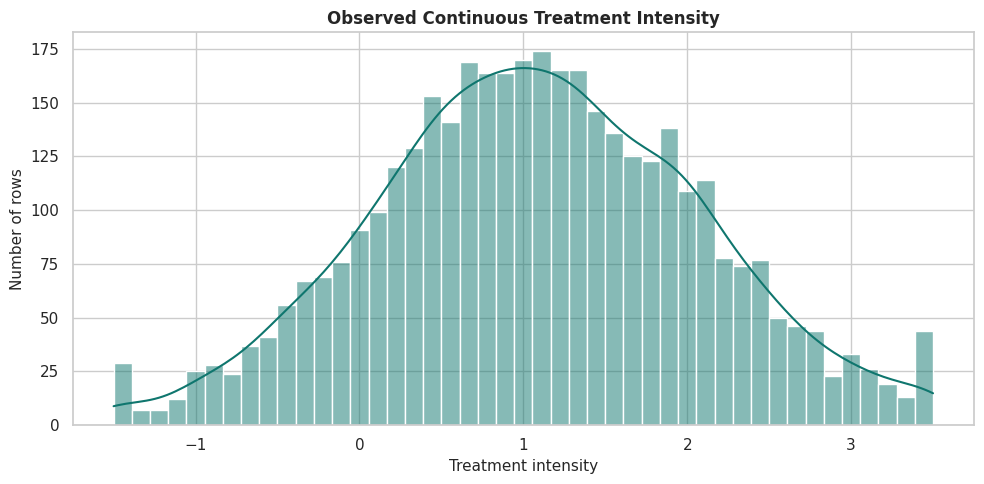

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(continuous_df["treatment_intensity"], bins=45, kde=True, color="#0f766e", ax=ax)
ax.set_title("Observed Continuous Treatment Intensity")
ax.set_xlabel("Treatment intensity")
ax.set_ylabel("Number of rows")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_continuous_treatment_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment distribution is continuous with useful spread. Boundary mass would make some dose contrasts less credible, so it is worth checking before model fitting.


#### True Marginal Effect Distribution

This plot shows the true heterogeneous slope. In real data, this distribution is unknown; here it gives us a target for evaluating the estimated marginal effects.


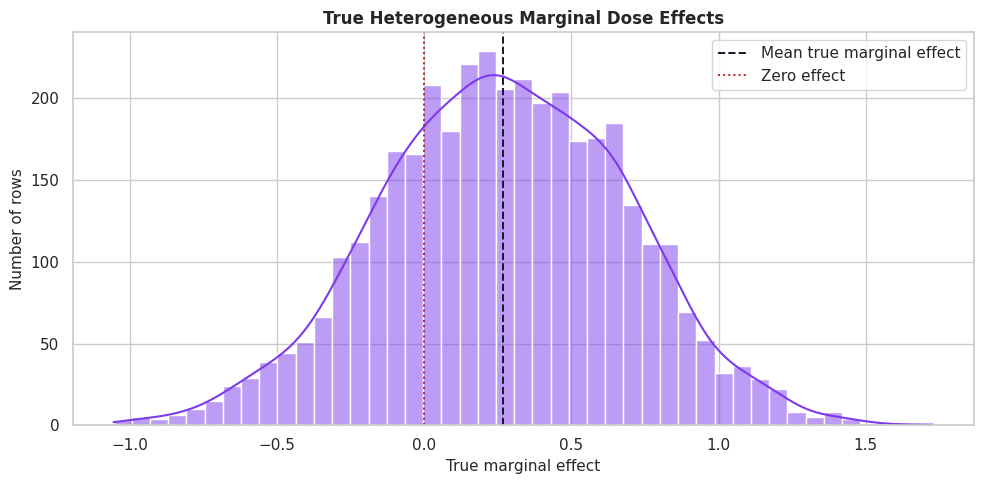

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(continuous_df["true_marginal_effect"], bins=45, kde=True, color="#7c3aed", ax=ax)
ax.axvline(continuous_df["true_marginal_effect"].mean(), color="#111827", linestyle="--", linewidth=1.4, label="Mean true marginal effect")
ax.axvline(0, color="#b91c1c", linestyle=":", linewidth=1.4, label="Zero effect")
ax.set_title("True Heterogeneous Marginal Dose Effects")
ax.set_xlabel("True marginal effect")
ax.set_ylabel("Number of rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_continuous_true_marginal_effect_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The marginal effect is positive for many rows and negative or weak for others. A dose-increase policy should therefore be selective and grounded in the estimated dose response.




#### Dose Support by Segment

For continuous treatments, support means having dose variation within the segments where we want to estimate effects. The code below summarizes dose distributions by high-capacity segment.


In [23]:
dose_support_by_segment = (
    continuous_df.assign(capacity_segment=np.where(continuous_df["high_capacity_segment"] == 1, "high capacity", "regular capacity"))
    .groupby("capacity_segment", observed=True)
    .agg(
        rows=("treatment_intensity", "size"),
        dose_mean=("treatment_intensity", "mean"),
        dose_std=("treatment_intensity", "std"),
        dose_min=("treatment_intensity", "min"),
        dose_p10=("treatment_intensity", lambda s: s.quantile(0.10)),
        dose_p90=("treatment_intensity", lambda s: s.quantile(0.90)),
        dose_max=("treatment_intensity", "max"),
        true_marginal_effect_mean=("true_marginal_effect", "mean"),
    )
    .reset_index()
)
dose_support_by_segment.to_csv(TABLE_DIR / "10_continuous_dose_support_by_segment.csv", index=False)
display(dose_support_by_segment)


,capacity_segment,rows,dose_mean,dose_std,dose_min,dose_p10,dose_p90,dose_max,true_marginal_effect_mean
0,high capacity,1377,1.332073,0.973032,-1.5,0.115144,2.648401,3.5,0.371357
1,regular capacity,2423,0.942369,0.975776,-1.5,-0.338502,2.204940,3.5,0.209445


Both segments have variation in treatment intensity. If one segment had almost no dose variation, its marginal-effect estimate would be much harder to trust.


#### Continuous Train-Test Split

We split the continuous-treatment data before fitting the model. Because the treatment is continuous, we stratify on a binned version of dose to keep dose ranges represented in both train and test splits.


In [24]:
continuous_feature_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "capacity_score",
    "account_tenure",
    "region_risk",
    "high_capacity_segment",
]
dose_bins = pd.qcut(continuous_df["treatment_intensity"], q=5, labels=False, duplicates="drop")
continuous_train, continuous_test = train_test_split(
    continuous_df,
    test_size=0.35,
    random_state=202611,
    stratify=dose_bins,
)
continuous_train = continuous_train.reset_index(drop=True)
continuous_test = continuous_test.reset_index(drop=True)
continuous_split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(continuous_train), len(continuous_test)],
        "dose_mean": [continuous_train["treatment_intensity"].mean(), continuous_test["treatment_intensity"].mean()],
        "dose_std": [continuous_train["treatment_intensity"].std(), continuous_test["treatment_intensity"].std()],
        "outcome_mean": [continuous_train["outcome"].mean(), continuous_test["outcome"].mean()],
        "true_marginal_effect_mean": [continuous_train["true_marginal_effect"].mean(), continuous_test["true_marginal_effect"].mean()],
    }
)
continuous_split_summary.to_csv(TABLE_DIR / "10_continuous_train_test_split_summary.csv", index=False)
display(continuous_split_summary)


,split,rows,dose_mean,dose_std,outcome_mean,true_marginal_effect_mean
0,train,2470,1.082995,0.999654,1.865068,0.271968
1,test,1330,1.084682,0.979441,1.812190,0.260965


The train and test splits have similar dose and true-effect distributions. That keeps held-out marginal-effect diagnostics meaningful.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Continuous Model Matrices

The code below extracts the covariates, continuous treatment vector, and outcome vector for `LinearDML`. Unlike the multi-arm section, `T` is numeric and continuous.


In [25]:
X_cont_train = continuous_train[continuous_feature_cols].copy()
X_cont_test = continuous_test[continuous_feature_cols].copy()
T_cont_train = continuous_train["treatment_intensity"].to_numpy()
T_cont_test = continuous_test["treatment_intensity"].to_numpy()
y_cont_train = continuous_train["outcome"].to_numpy()
y_cont_test = continuous_test["outcome"].to_numpy()
true_slope_test = continuous_test["true_marginal_effect"].to_numpy()
continuous_matrix_summary = pd.DataFrame(
    {
        "object": ["X_cont_train", "X_cont_test", "T_cont_train", "y_cont_train"],
        "shape_or_length": [X_cont_train.shape, X_cont_test.shape, len(T_cont_train), len(y_cont_train)],
        "description": [
            "Observed pre-treatment covariates.",
            "Held-out covariates for marginal-effect evaluation.",
            "Continuous treatment intensity for training rows.",
            "Observed outcomes for training rows.",
        ],
    }
)
continuous_matrix_summary.to_csv(TABLE_DIR / "10_continuous_model_matrix_summary.csv", index=False)
display(continuous_matrix_summary)


,object,shape_or_length,description
0,X_cont_train,"(2470, 9)",Observed pre-treatment covariates.
1,X_cont_test,"(1330, 9)",Held-out covariates for marginal-effect evaluation.
2,T_cont_train,2470,Continuous treatment intensity for training rows.
3,y_cont_train,2470,Observed outcomes for training rows.


The continuous treatment vector has the same length as the outcome vector, but its values are real-valued doses rather than treatment-arm labels.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->




#### Continuous Nuisance Diagnostics

`LinearDML` residualizes both the outcome and the continuous treatment. This diagnostic cell checks whether observed covariates predict the treatment intensity and outcome reasonably well.


In [26]:
# Fit or evaluate the model objects used in the Continuous Nuisance Diagnostics section.
dose_model_diagnostic = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=20,
    random_state=202615,
    n_jobs=-1,
)
dose_model_diagnostic.fit(X_cont_train, T_cont_train)
dose_pred = dose_model_diagnostic.predict(X_cont_test)
continuous_outcome_features_train = X_cont_train.assign(treatment_intensity=T_cont_train)
continuous_outcome_features_test = X_cont_test.assign(treatment_intensity=T_cont_test)
continuous_outcome_diagnostic = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=20,
    random_state=202616,
    n_jobs=-1,
)
continuous_outcome_diagnostic.fit(continuous_outcome_features_train, y_cont_train)
continuous_outcome_pred = continuous_outcome_diagnostic.predict(continuous_outcome_features_test)
continuous_nuisance_diagnostics = pd.DataFrame(
    [
        {
            "model": "dose_model",
            "metric_1": "rmse",
            "value_1": np.sqrt(mean_squared_error(T_cont_test, dose_pred)),
            "metric_2": "mae",
            "value_2": mean_absolute_error(T_cont_test, dose_pred),
        },
        {
            "model": "outcome_model",
            "metric_1": "rmse",
            "value_1": np.sqrt(mean_squared_error(y_cont_test, continuous_outcome_pred)),
            "metric_2": "mae",
            "value_2": mean_absolute_error(y_cont_test, continuous_outcome_pred),
        },
    ]
)
continuous_nuisance_diagnostics.to_csv(TABLE_DIR / "10_continuous_nuisance_diagnostics.csv", index=False)
display(continuous_nuisance_diagnostics)


,model,metric_1,value_1,metric_2,value_2
0,dose_model,rmse,0.738349,mae,0.592988
1,outcome_model,rmse,0.884495,mae,0.701308


The dose model captures confounding in the treatment intensity. That is exactly the structure DML is designed to handle: remove predictable treatment and outcome components, then estimate the residualized treatment effect.




#### Fit LinearDML for Continuous Treatment

`LinearDML` estimates a CATE function that is linear in the treatment but can vary with covariates. In this synthetic data, the outcome is linear in dose with a heterogeneous slope, so the estimator is aligned with the teaching setup.


In [27]:
continuous_dml = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=240,
        min_samples_leaf=20,
        random_state=202617,
        n_jobs=-1,
    ),
    model_t=RandomForestRegressor(
        n_estimators=240,
        min_samples_leaf=20,
        random_state=202618,
        n_jobs=-1,
    ),
    cv=3,
    random_state=202619,
)
continuous_dml.fit(y_cont_train, T_cont_train, X=X_cont_train, inference="statsmodels")
estimated_marginal_effect = np.ravel(continuous_dml.const_marginal_effect(X_cont_test))
estimated_effect_0_to_1 = np.ravel(continuous_dml.effect(X_cont_test, T0=0, T1=1))
estimated_effect_0_to_2 = np.ravel(continuous_dml.effect(X_cont_test, T0=0, T1=2))
print(f"Mean estimated marginal effect: {estimated_marginal_effect.mean():.4f}")
print(f"Mean true marginal effect: {true_slope_test.mean():.4f}")


Mean estimated marginal effect: 0.4192
Mean true marginal effect: 0.2610


For a linear-in-dose treatment model, the one-unit effect from `effect(X, T0=0, T1=1)` should match the marginal effect. The two-unit contrast should be roughly twice the marginal effect.




#### Continuous Effect Recovery

The code below compares estimated marginal effects and finite dose contrasts with the synthetic truth. These recovery metrics are diagnostics that would not be available in real observational data.


In [28]:
continuous_eval = continuous_test[continuous_feature_cols + ["treatment_intensity", "outcome", "true_marginal_effect", "true_effect_0_to_1", "true_effect_0_to_2"]].copy()
continuous_eval["estimated_marginal_effect"] = estimated_marginal_effect
continuous_eval["estimated_effect_0_to_1"] = estimated_effect_0_to_1
continuous_eval["estimated_effect_0_to_2"] = estimated_effect_0_to_2
continuous_recovery = pd.DataFrame(
    [
        {
            "quantity": "marginal effect",
            "true_mean": continuous_eval["true_marginal_effect"].mean(),
            "estimated_mean": continuous_eval["estimated_marginal_effect"].mean(),
            "rmse": np.sqrt(mean_squared_error(continuous_eval["true_marginal_effect"], continuous_eval["estimated_marginal_effect"])),
            "mae": mean_absolute_error(continuous_eval["true_marginal_effect"], continuous_eval["estimated_marginal_effect"]),
            "correlation": np.corrcoef(continuous_eval["true_marginal_effect"], continuous_eval["estimated_marginal_effect"])[0, 1],
        },
        {
            "quantity": "effect from dose 0 to 1",
            "true_mean": continuous_eval["true_effect_0_to_1"].mean(),
            "estimated_mean": continuous_eval["estimated_effect_0_to_1"].mean(),
            "rmse": np.sqrt(mean_squared_error(continuous_eval["true_effect_0_to_1"], continuous_eval["estimated_effect_0_to_1"])),
            "mae": mean_absolute_error(continuous_eval["true_effect_0_to_1"], continuous_eval["estimated_effect_0_to_1"]),
            "correlation": np.corrcoef(continuous_eval["true_effect_0_to_1"], continuous_eval["estimated_effect_0_to_1"])[0, 1],
        },
        {
            "quantity": "effect from dose 0 to 2",
            "true_mean": continuous_eval["true_effect_0_to_2"].mean(),
            "estimated_mean": continuous_eval["estimated_effect_0_to_2"].mean(),
            "rmse": np.sqrt(mean_squared_error(continuous_eval["true_effect_0_to_2"], continuous_eval["estimated_effect_0_to_2"])),
            "mae": mean_absolute_error(continuous_eval["true_effect_0_to_2"], continuous_eval["estimated_effect_0_to_2"]),
            "correlation": np.corrcoef(continuous_eval["true_effect_0_to_2"], continuous_eval["estimated_effect_0_to_2"])[0, 1],
        },
    ]
)
continuous_recovery.to_csv(TABLE_DIR / "10_continuous_effect_recovery.csv", index=False)
continuous_eval.to_csv(TABLE_DIR / "10_continuous_heldout_effects.csv", index=False)
display(continuous_recovery)


,quantity,true_mean,estimated_mean,rmse,mae,correlation
0,marginal effect,0.260965,0.419174,0.170118,0.158330,0.988406
1,effect from dose 0 to 1,0.260965,0.419174,0.170118,0.158330,0.988406
2,effect from dose 0 to 2,0.521930,0.838347,0.340237,0.316659,0.988406


The recovery table checks whether the estimated slope and finite contrasts move with the truth. The finite contrasts scale with the dose change because the synthetic outcome is linear in treatment intensity.


#### Continuous Marginal-Effect Recovery Plot

The next plot compares true and estimated marginal effects for held-out rows. The diagonal line is perfect recovery.


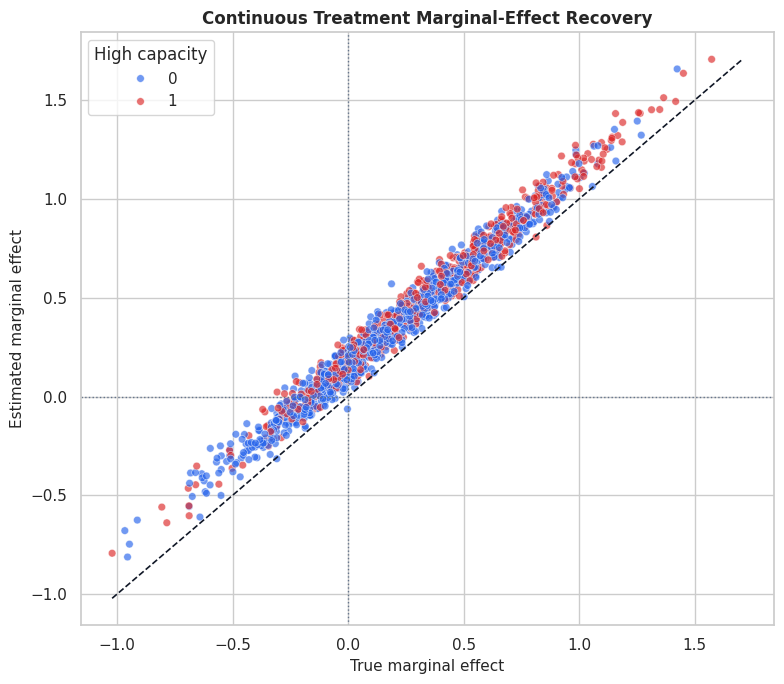

In [29]:
# Build and label the diagnostic visualization for the Continuous Marginal-Effect Recovery Plot section.
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    data=continuous_eval,
    x="true_marginal_effect",
    y="estimated_marginal_effect",
    hue="high_capacity_segment",
    palette={0: "#2563eb", 1: "#dc2626"},
    alpha=0.65,
    s=30,
    ax=ax,
)
lims = [
    min(continuous_eval["true_marginal_effect"].min(), continuous_eval["estimated_marginal_effect"].min()),
    max(continuous_eval["true_marginal_effect"].max(), continuous_eval["estimated_marginal_effect"].max()),
]
ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1.2)
ax.axhline(0, color="#64748b", linestyle=":", linewidth=1)
ax.axvline(0, color="#64748b", linestyle=":", linewidth=1)
ax.set_title("Continuous Treatment Marginal-Effect Recovery")
ax.set_xlabel("True marginal effect")
ax.set_ylabel("Estimated marginal effect")
ax.legend(title="High capacity")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_continuous_marginal_effect_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The scatterplot shows how well the estimated marginal effect tracks the true slope. Segment coloring helps reveal whether recovery differs across capacity groups.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Dose Contrast Sanity Check

Because the teaching outcome is linear in dose, the estimated effect from dose `0` to `2` should be about twice the estimated effect from dose `0` to `1`. The code below checks that relationship directly.


In [30]:
dose_contrast_check = pd.DataFrame(
    {
        "metric": [
            "mean_estimated_effect_0_to_1",
            "mean_estimated_effect_0_to_2",
            "ratio_0_to_2_over_0_to_1",
            "mean_absolute_difference_between_2x_and_0_to_2",
        ],
        "value": [
            continuous_eval["estimated_effect_0_to_1"].mean(),
            continuous_eval["estimated_effect_0_to_2"].mean(),
            continuous_eval["estimated_effect_0_to_2"].mean() / continuous_eval["estimated_effect_0_to_1"].mean(),
            np.mean(np.abs(2 * continuous_eval["estimated_effect_0_to_1"] - continuous_eval["estimated_effect_0_to_2"])),
        ],
    }
)
dose_contrast_check.to_csv(TABLE_DIR / "10_continuous_dose_contrast_check.csv", index=False)
display(dose_contrast_check)


,metric,value
0,mean_estimated_effect_0_to_1,0.419174
1,mean_estimated_effect_0_to_2,0.838347
2,ratio_0_to_2_over_0_to_1,2.000000
3,mean_absolute_difference_between_2x_and_0_to_2,0.000000


The ratio and absolute difference confirm the expected linear-dose behavior. If the real causal question involved nonlinear saturation, we would need a treatment featurizer or a different dose-response strategy.


#### Segment-Level Continuous Effects

The code below summarizes estimated and true marginal effects by capacity and need segments. Segment summaries are often easier to communicate than row-level slopes.


In [31]:
continuous_segment_eval = continuous_eval.copy()
continuous_segment_eval["capacity_segment"] = np.where(continuous_segment_eval["high_capacity_segment"] == 1, "high capacity", "regular capacity")
continuous_segment_eval["need_segment"] = np.where(continuous_segment_eval["baseline_need"] > continuous_segment_eval["baseline_need"].median(), "higher need", "lower need")
continuous_segment_summary = (
    continuous_segment_eval.groupby(["capacity_segment", "need_segment"], observed=True)
    .agg(
        rows=("outcome", "size"),
        dose_mean=("treatment_intensity", "mean"),
        true_marginal_effect_mean=("true_marginal_effect", "mean"),
        estimated_marginal_effect_mean=("estimated_marginal_effect", "mean"),
        true_effect_0_to_2_mean=("true_effect_0_to_2", "mean"),
        estimated_effect_0_to_2_mean=("estimated_effect_0_to_2", "mean"),
        share_estimated_positive=("estimated_marginal_effect", lambda s: np.mean(s > 0)),
    )
    .reset_index()
)
continuous_segment_summary.to_csv(TABLE_DIR / "10_continuous_segment_summary.csv", index=False)
display(continuous_segment_summary)


,capacity_segment,need_segment,rows,dose_mean,true_marginal_effect_mean,estimated_marginal_effect_mean,true_effect_0_to_2_mean,estimated_effect_0_to_2_mean,share_estimated_positive
0,high capacity,higher need,244,1.666521,0.588862,0.758568,1.177724,1.517137,0.991803
1,high capacity,lower need,244,0.977828,0.119577,0.288660,0.239154,0.577319,0.799180
2,regular capacity,higher need,421,1.205265,0.417008,0.575637,0.834016,1.151274,0.957245
3,regular capacity,lower need,421,0.688809,-0.003173,0.141648,-0.006346,0.283296,0.665083


The segment table shows where increased treatment intensity appears most beneficial. It also exposes whether some segments have weaker estimated dose effects despite similar average dose levels.


#### Segment Continuous-Effect Plot

This plot compares true and estimated marginal effects by segment. It is a compact way to explain heterogeneous continuous-dose effects.


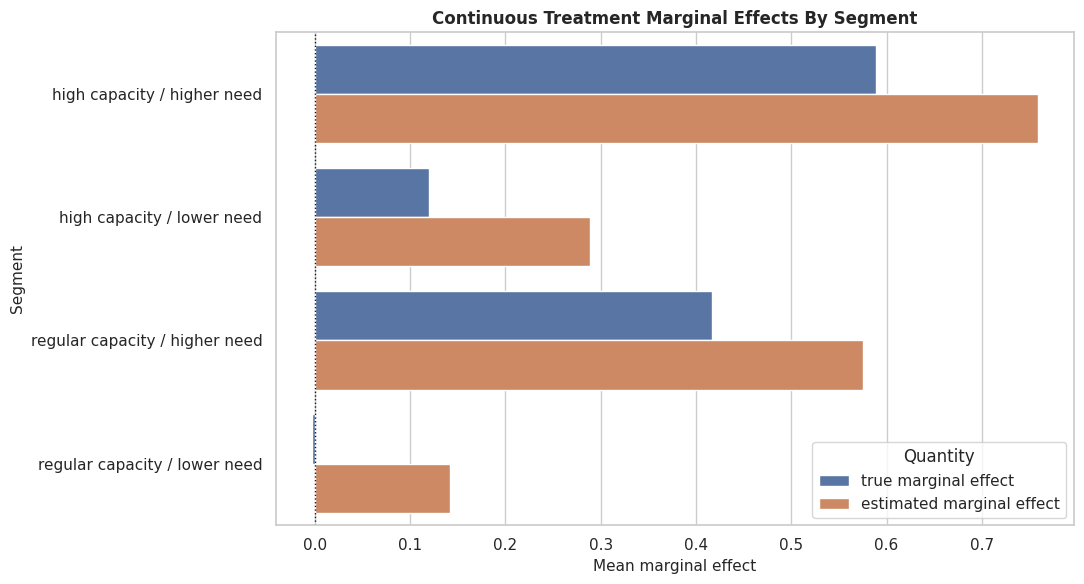

In [32]:
cont_segment_plot = continuous_segment_summary.copy()
cont_segment_plot["segment"] = cont_segment_plot["capacity_segment"] + " / " + cont_segment_plot["need_segment"]
cont_segment_long = cont_segment_plot.melt(
    id_vars="segment",
    value_vars=["true_marginal_effect_mean", "estimated_marginal_effect_mean"],
    var_name="quantity",
    value_name="marginal_effect",
)
cont_segment_long["quantity"] = cont_segment_long["quantity"].map(
    {
        "true_marginal_effect_mean": "true marginal effect",
        "estimated_marginal_effect_mean": "estimated marginal effect",
    }
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=cont_segment_long, x="marginal_effect", y="segment", hue="quantity", ax=ax)
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Continuous Treatment Marginal Effects By Segment")
ax.set_xlabel("Mean marginal effect")
ax.set_ylabel("Segment")
ax.legend(title="Quantity")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_continuous_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The segment plot shows whether the estimator preserves the broad ranking of groups. This is often more important for decision-making than perfect row-level recovery.




#### Dose-Increase Targeting Rule

A continuous-treatment model can support a policy such as “increase dose for rows whose estimated marginal effect is positive and high enough.” The code below compares a simple estimated rule to an oracle rule using the synthetic truth.


In [33]:
dose_increase_cost = 0.08
continuous_eval["estimated_increase_rule"] = (continuous_eval["estimated_marginal_effect"] > dose_increase_cost).astype(int)
continuous_eval["oracle_increase_rule"] = (continuous_eval["true_marginal_effect"] > dose_increase_cost).astype(int)
continuous_policy_summary = pd.DataFrame(
    [
        {
            "policy": "estimated marginal effect > cost",
            "increase_rate": continuous_eval["estimated_increase_rule"].mean(),
            "mean_true_net_gain_among_selected": (continuous_eval.loc[continuous_eval["estimated_increase_rule"] == 1, "true_marginal_effect"] - dose_increase_cost).mean(),
            "population_true_net_gain": ((continuous_eval["true_marginal_effect"] - dose_increase_cost) * continuous_eval["estimated_increase_rule"]).mean(),
            "share_selected_with_negative_net_truth": ((continuous_eval.loc[continuous_eval["estimated_increase_rule"] == 1, "true_marginal_effect"] - dose_increase_cost) < 0).mean(),
        },
        {
            "policy": "oracle marginal effect > cost",
            "increase_rate": continuous_eval["oracle_increase_rule"].mean(),
            "mean_true_net_gain_among_selected": (continuous_eval.loc[continuous_eval["oracle_increase_rule"] == 1, "true_marginal_effect"] - dose_increase_cost).mean(),
            "population_true_net_gain": ((continuous_eval["true_marginal_effect"] - dose_increase_cost) * continuous_eval["oracle_increase_rule"]).mean(),
            "share_selected_with_negative_net_truth": ((continuous_eval.loc[continuous_eval["oracle_increase_rule"] == 1, "true_marginal_effect"] - dose_increase_cost) < 0).mean(),
        },
    ]
)
continuous_policy_summary.to_csv(TABLE_DIR / "10_continuous_dose_increase_policy_summary.csv", index=False)
display(continuous_policy_summary)


,policy,increase_rate,mean_true_net_gain_among_selected,population_true_net_gain,share_selected_with_negative_net_truth
0,estimated marginal effect > cost,0.789474,0.328009,0.258955,0.178095
1,oracle marginal effect > cost,0.648872,0.418522,0.271567,0.000000


The estimated rule is a realistic version of dose targeting: it uses model-estimated marginal effects and a cost threshold. The oracle row shows the upper benchmark that would be available only if true effects were known.




#### Dose-Increase Policy Plot

The final policy plot compares increase rates and true net gains under the estimated and oracle dose-increase rules.


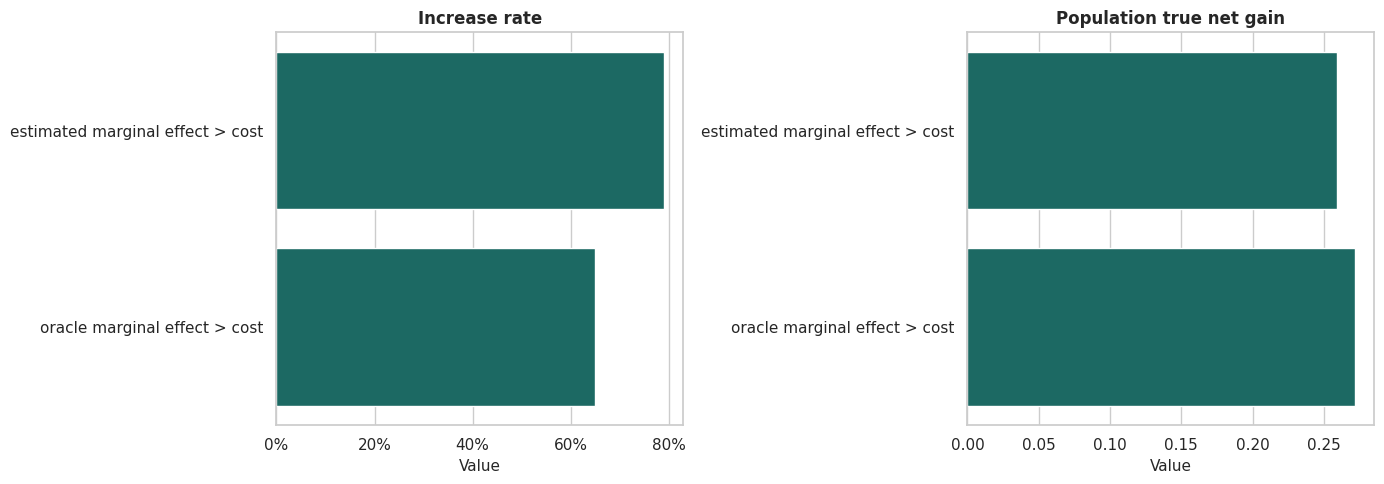

In [34]:
continuous_policy_plot = continuous_policy_summary.melt(
    id_vars="policy",
    value_vars=["increase_rate", "population_true_net_gain"],
    var_name="metric",
    value_name="value",
)
continuous_policy_plot["metric"] = continuous_policy_plot["metric"].map(
    {
        "increase_rate": "Increase rate",
        "population_true_net_gain": "Population true net gain",
    }
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, continuous_policy_plot["metric"].unique()):
    subset = continuous_policy_plot[continuous_policy_plot["metric"] == metric]
    sns.barplot(data=subset, x="value", y="policy", color="#0f766e", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    if metric == "Increase rate":
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_continuous_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The policy plot translates marginal effects into a decision. Even in a continuous-dose setting, the model often becomes useful through a clear rule that says where to increase, decrease, or hold intensity.




#### Practical Checklist

The final checklist summarizes what to verify before using multiple-treatment or continuous-treatment estimates in a real analysis.


| topic | multi_arm_question | continuous_question |
| --- | --- | --- |
| Treatment definition | Are arms mutually exclusive and clearly named? | Is the dose numeric, ordered, and measured before the outcome window? |
| Reference contrast | Which arm is the baseline for effect estimates? | Which finite dose contrast or marginal effect is being reported? |
| Overlap and support | Does every arm have support in the covariate regions being compared? | Is there enough dose variation within important segments? |
| Nuisance models | Can the arm assignment and outcome models learn useful signal? | Can the dose and outcome models learn useful signal? |
| Decision rule | Will action use best-arm ranking, budget constraints, or arm-specific thresholds? | Will action use marginal-effect thresholds, dose caps, or cost-adjusted net effects? |
| Reporting | Report arm-specific effects and the arm mix of the learned policy. | Report marginal effects, dose support, and the dose range where results apply. |


The checklist keeps the final analysis grounded. Multiple treatments and continuous treatments are powerful, but they require careful contrast definitions and support diagnostics.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->


## Summary

This lesson extended the EconML tutorial sequence beyond binary treatments.

The multi-arm section showed how to:

- define a baseline arm and active-arm contrasts;
- estimate arm-specific CATEs with `DRLearner`;
- compare active arms for the same row;
- convert arm effects into an estimated best-arm policy;
- evaluate arm-specific recovery and policy regret on synthetic truth.

The continuous-treatment section showed how to:

- define marginal effects and finite dose contrasts;
- inspect dose support before modeling;
- estimate heterogeneous dose slopes with `LinearDML`;
- compare estimated slopes with known synthetic truth;
- turn marginal effects into a dose-increase rule.

The sequence next introduces instrumental-variable estimators, which are useful when treatment is confounded by unobserved factors and a credible instrument is available.
